In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model

In [40]:
model_path = "../home/ARO.local/collaboration/sagi-tomer-collab/Normalized_Tomato_Seeds/Models/ManualCNNClassifier_0-320-639-bands-0.5-accuracy_model.keras"
image_path = "../home/ARO.local/collaboration/sagi-tomer-collab/Normalized_Tomato_Seeds/Healthy/Tray_1_row_3_column_0.npy"
layer_index = 3
topk = 5

In [31]:
# Function to load and preprocess the image
def load_and_preprocess_image(image_path, model, chosen_channels=None):
    # Load the image
    image = np.load(image_path)

    # Resize image to match model input shape
    input_shape = model.input_shape[1:]  # (H, W, C)
    if image.shape[:3] != input_shape[:3]:  # Check if only spatial dimensions need resizing
        image = tf.image.resize(image, input_shape[:2]).numpy()

    # If chosen_channels is provided, select them from the image
    if chosen_channels is not None:
        image = image[:, :, chosen_channels]
    
    # Ensure the image is in float32 format
    image = image.astype(np.float32)

    # Add batch dimension (make it (1, H, W, C))
    image = np.expand_dims(image, axis=0)

    print(f"Loaded and processed image shape: {image.shape}")
    return image


# Load the model
model = load_model(model_path)

# Define the chosen channels (optional)
chosen_channels = [10, 50, 100]  # Example channels to select

# Load and preprocess the image
image = load_and_preprocess_image(image_path, model, chosen_channels)

Loaded and processed image shape: (1, 91, 110, 3)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Feature map shape: (22, 27, 64)
22 27 64


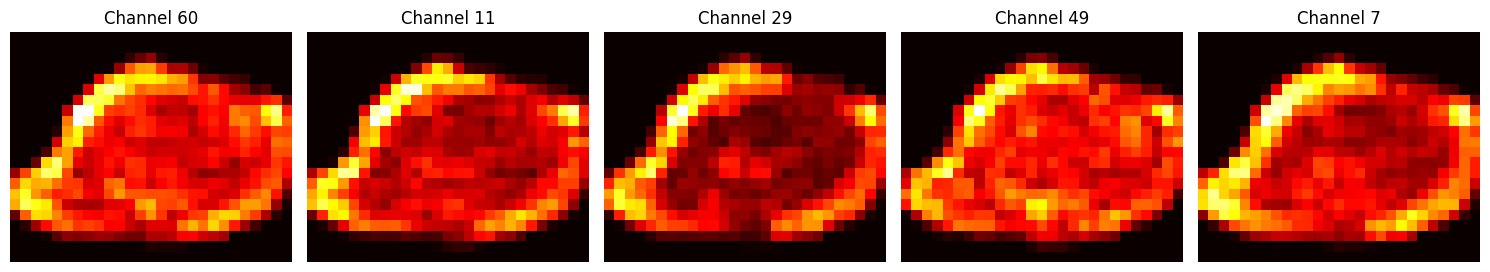

In [41]:
def visualize_topk_activations(model, image, layer_index, topk=5):
    # Access layer by index
    layer = model.layers[layer_index]
    intermediate_model = tf.keras.Model(inputs=model.inputs[0], outputs=layer.output)

    # Get activation map
    feature_maps = intermediate_model.predict(image)[0]  # shape: (H, W, C)
    
    # Print shape of the feature map for debugging
    print(f"Feature map shape: {feature_maps.shape}")

    # Check if the feature map has 3 dimensions (H, W, C)
    if feature_maps.ndim != 3:
        print(f"Feature map has {feature_maps.ndim} dimensions, not 3D.")
        print("Attempting to reshape or process differently.")
        return

    # If it's 3D, proceed
    H, W, C = feature_maps.shape
    print(H, W, C)

    # Mean activation per channel
    scores = feature_maps.reshape(-1, C).mean(axis=0)
    top_indices = np.argsort(scores)[-topk:][::-1]

    # Plot top-K maps
    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(top_indices):
        plt.subplot(1, topk, i + 1)
        plt.imshow(feature_maps[..., idx], cmap='hot')
        plt.title(f"Channel {idx}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Run
visualize_topk_activations(model, image, layer_index, topk=topk)

In [ ]:
print("Available layer names:")
for i, layer in enumerate(model.layers):
    print(f"{i}: {layer.name} - {layer.output_shape}")